# Validate `movies_final.csv` / `ratings_final.csv`

In [1]:
import sys
import os
sys.path.append("/Users/aryanshah/Developer/Thesis/recosys/src")   

import pandas as pd
import numpy as np

from mappings import (
    CANONICAL_GENRES, UNKNOWN_GENRE_LABEL,
    CANONICAL_LANGUAGE_MAP, UNKNOWN_LANGUAGE_LABEL,
)

MOVIES_PATH = (
    "/Users/aryanshah/Developer/Thesis/recosys/data/processed/movies_final.csv"
)
RATINGS_PATH = (
    "/Users/aryanshah/Developer/Thesis/recosys/data/processed/ratings_final.csv"
)

movies = pd.read_csv(MOVIES_PATH)
ratings = pd.read_csv(RATINGS_PATH)

print("movies_final:", movies.shape)
print("ratings_final:", ratings.shape)
movies.head()

movies_final: (87585, 11)
ratings_final: (31722400, 3)


,movieId,tmdbId,title,ml_genres,clean_genres,language,overview,release_year,vote_average,vote_count,popularity
0,1,862.0,Toy Story (1995),Adventure|Animation|Comedy|Fantasy|Other,Animation|Comedy|Family,English,"Led by Woody, Andy's toys live happily in his ...",1995.0,7.7,5415,21.946943
1,2,8844.0,Jumanji (1995),Adventure|Fantasy|Other,Adventure|Family|Fantasy,English,When siblings Judy and Peter discover an encha...,1995.0,6.9,2413,17.015539
2,3,15602.0,Grumpier Old Men (1995),Comedy|Romance,Comedy|Romance,English,A family wedding reignites the ancient feud be...,1995.0,6.5,92,11.712900
3,4,31357.0,Waiting to Exhale (1995),Comedy|Drama|Romance,Comedy|Drama|Romance,English,"Cheated on, mistreated and stepped on, the wom...",1995.0,6.1,34,3.859495
4,5,11862.0,Father of the Bride Part II (1995),Comedy,Comedy,English,Just when George Banks has recovered from his ...,1995.0,5.7,173,8.387519


## 1. Schema

In [2]:
REQUIRED_MOVIE_COLUMNS = ["movieId","tmdbId","title","ml_genres","clean_genres",
                           "language","overview","release_year","vote_average",
                           "vote_count","popularity"]

missing_cols = [c for c in REQUIRED_MOVIE_COLUMNS if c not in movies.columns]
print("Missing columns:", missing_cols or "None")
movies.dtypes

Missing columns: None


movieId           int64
tmdbId          float64
title               str
ml_genres           str
clean_genres        str
language            str
overview            str
release_year    float64
vote_average    float64
vote_count        int64
popularity      float64
dtype: object

## 2. Nulls / duplicates — movies_final

In [3]:
dup_movie_ids = movies["movieId"].duplicated().sum()
null_movie_ids = movies["movieId"].isna().sum()
empty_genres = (movies["clean_genres"] == "").sum()
empty_lang = (movies["language"] == "").sum()

print("Duplicate movieId rows:", dup_movie_ids)
print("Null movieId:", null_movie_ids)
print("Empty clean_genres:", empty_genres)
print("Empty language:", empty_lang)
print()
movies.isna().sum()

Duplicate movieId rows: 0
Null movieId: 0
Empty clean_genres: 0
Empty language: 0



movieId             0
tmdbId            124
title               0
ml_genres           0
clean_genres        0
language            0
overview        45540
release_year      505
vote_average        0
vote_count          0
popularity          0
dtype: int64

In [4]:
tmdb_raw = pd.read_csv(
    "/Users/aryanshah/Developer/Thesis/recosys/data/raw/tmdb/movies_metadata.csv",
    low_memory=False,
)
tmdb_raw["original_language"].value_counts().head(20)


original_language
en    32269
fr     2438
it     1529
ja     1350
de     1080
es      994
ru      826
hi      508
ko      444
zh      409
sv      384
pt      316
cn      313
fi      297
nl      248
da      225
pl      219
tr      150
cs      130
el      113
Name: count, dtype: int64

## 3. Genre vocabulary

In [5]:
valid_genre_tokens = set(CANONICAL_GENRES) | {UNKNOWN_GENRE_LABEL}

all_tokens = set()
for g in movies["clean_genres"].dropna():
    all_tokens.update(g.split("|"))

invalid_genre_tokens = all_tokens - valid_genre_tokens
print("Invalid genre tokens:", invalid_genre_tokens or "None — all canonical")

genre_counts = pd.Series(
    [t for g in movies["clean_genres"].dropna() for t in g.split("|")]
).value_counts()
genre_counts

Invalid genre tokens: None — all canonical


Drama          35221
Comedy         23669
Thriller       12701
Romance        11159
Action         10522
Other           9993
Documentary     9489
Horror          8906
Crime           7156
Adventure       5593
Sci-Fi          5098
Animation       4661
Mystery         4263
Fantasy         4021
Family          2635
War             2165
Western         1726
Music           1548
History         1330
TV               690
Name: count, dtype: int64

## 4. Language vocabulary

In [6]:
from mappings import MISSING_LANGUAGE_LABEL

valid_langs = set(CANONICAL_LANGUAGE_MAP.values()) | {
    UNKNOWN_LANGUAGE_LABEL,
    MISSING_LANGUAGE_LABEL,
}
invalid_langs = set(movies["language"].dropna().unique()) - valid_langs
print("Invalid language labels:", invalid_langs or "None — all canonical")

movies["language"].value_counts()

Invalid language labels: None — all canonical


language
Unknown       44644
English       30403
French         2350
Italian        1490
Japanese       1233
Other          1139
German         1021
Spanish         948
Russian         806
Chinese         683
Hindi           500
Korean          428
Swedish         333
Portuguese      299
Finnish         271
Dutch           243
Polish          213
Danish          212
Turkish         136
Czech           122
Greek           109
Nepali            2
Name: count, dtype: int64

## 5. release_year sanity

In [7]:
print("release_year range:", movies["release_year"].min(), "-", movies["release_year"].max())
missing_year_pct = movies["release_year"].isna().mean()
print(f"Missing release_year: {movies['release_year'].isna().sum()} ({missing_year_pct:.1%})")

bad_years = movies[(movies["release_year"] < 1888) | (movies["release_year"] > 2026)]
print("Implausible years (<1888 or >2026):", len(bad_years))

release_year range: 1874.0 - 2023.0
Missing release_year: 505 (0.6%)
Implausible years (<1888 or >2026): 11


## 6. overview coverage

In [8]:
empty_overview = (movies["overview"] == "").sum()
print(f"Empty overview: {empty_overview} ({empty_overview/len(movies):.1%})")

Empty overview: 0 (0.0%)


## 7. ratings_final — validity

In [9]:
bad_rating_range = (~ratings["rating"].between(0.5, 5.0)).sum()
null_user = ratings["userId"].isna().sum()
null_movie = ratings["movieId"].isna().sum()
dup_pairs = ratings.duplicated(subset=["userId","movieId"]).sum()

print("Ratings outside [0.5, 5.0]:", bad_rating_range)
print("Null userId:", null_user)
print("Null movieId:", null_movie)
print("Duplicate (userId, movieId) pairs:", dup_pairs)

Ratings outside [0.5, 5.0]: 0
Null userId: 0
Null movieId: 0
Duplicate (userId, movieId) pairs: 0


## 8. Orphan check
Every movieId in ratings must exist in movies_final — otherwise SVD trains on IDs the CBF/hybrid can't map back to metadata.

In [10]:
valid_ids = set(movies["movieId"])
orphans = ratings.loc[~ratings["movieId"].isin(valid_ids)]
print("Orphan ratings:", len(orphans))

Orphan ratings: 0


## 9. min-activity threshold actually holds
clean_data.py filters at >=20/>=20 iteratively — confirm nothing below that slipped through.

In [11]:
user_counts = ratings["userId"].value_counts()
movie_counts = ratings["movieId"].value_counts()

users_below = (user_counts < 20).sum()
movies_below = (movie_counts < 20).sum()

print("Users with <20 ratings:", users_below)
print("Movies with <20 ratings:", movies_below)
print("Unique users:", ratings['userId'].nunique(), "| Unique movies:", ratings['movieId'].nunique())

Users with <20 ratings: 0
Movies with <20 ratings: 0
Unique users: 200763 | Unique movies: 23339


## 10. Genre & language distribution (thesis-ready plots)

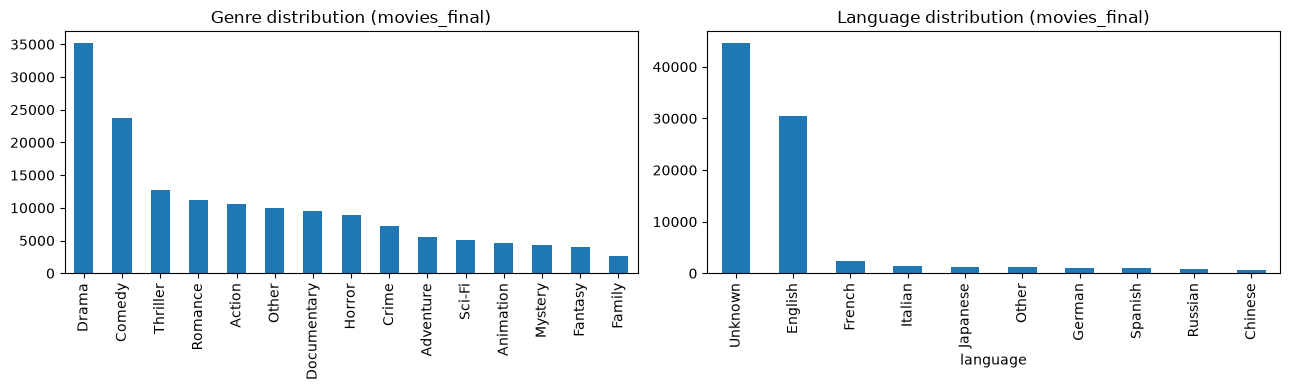

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
genre_counts.head(15).plot(kind="bar", ax=axes[0], title="Genre distribution (movies_final)")
movies["language"].value_counts().head(10).plot(kind="bar", ax=axes[1], title="Language distribution (movies_final)")
plt.tight_layout()
plt.show()

## 11. Summary — PASS/FAIL

In [13]:
checks = {
    "No missing required columns": len(missing_cols) == 0,
    "movieId unique in movies_final": dup_movie_ids == 0,
    "No null movieId": null_movie_ids == 0,
    "No empty clean_genres": empty_genres == 0,
    "No empty language": empty_lang == 0,
    "All genre tokens canonical": len(invalid_genre_tokens) == 0,
    "All language labels canonical": len(invalid_langs) == 0,
    "No implausible release_year": len(bad_years) == 0,
    "Ratings within [0.5, 5.0]": bad_rating_range == 0,
    "No null userId/movieId in ratings": null_user == 0 and null_movie == 0,
    "No duplicate rating pairs": dup_pairs == 0,
    "No orphan ratings": len(orphans) == 0,
    "Min-activity threshold (>=20) holds": users_below == 0 and movies_below == 0,
}

for name, passed in checks.items():
    print(("PASS" if passed else "FAIL"), "-", name)

print()
n_fail = sum(not v for v in checks.values())
print("ALL CHECKS PASSED" if n_fail == 0 else f"{n_fail} CHECK(S) FAILED — see above")

PASS - No missing required columns
PASS - movieId unique in movies_final
PASS - No null movieId
PASS - No empty clean_genres
PASS - No empty language
PASS - All genre tokens canonical
PASS - All language labels canonical
FAIL - No implausible release_year
PASS - Ratings within [0.5, 5.0]
PASS - No null userId/movieId in ratings
PASS - No duplicate rating pairs
PASS - No orphan ratings
PASS - Min-activity threshold (>=20) holds

1 CHECK(S) FAILED — see above
